# Assignment 3

Deadline: 09.04.2025 12:00 CET

<Add your name, student-id and emal address>

In [53]:
# Standard library imports
import os
import sys
import types

# Third party imports
import numpy as np
import pandas as pd

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))   #<Change this path if needed>
src_path = os.path.join(project_root, 'qpmwp-course/src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import load_data_msci
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.optimization import MeanVariance
from backtesting.backtest_item_builder_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder_functions import (
    bibfn_selection_data_random,
    bibfn_return_series,
    bibfn_budget_constraint,
    bibfn_box_constraints,
)
from backtesting.portfolio import floating_weights
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest

### Data load

In [54]:
N = 24
data = load_data_msci(path = '../data/', n = N)  #<Change the path if needed>
print(data)

{'return_series':                   AT        AU        BE        CA        CH        DE  \
Index                                                                    
1999-01-01  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1999-01-04  0.010057  0.009080  0.042147  0.013070  0.035885  0.052249   
1999-01-05  0.013661 -0.010048  0.020162  0.021940  0.012016  0.001444   
1999-01-06  0.000000  0.015264 -0.000078  0.027640  0.015335  0.036205   
1999-01-07  0.004104  0.016564 -0.016877 -0.003480 -0.011902 -0.020187   
...              ...       ...       ...       ...       ...       ...   
2023-04-12 -0.002488  0.004714 -0.012072  0.001708  0.000017  0.002662   
2023-04-13  0.001297 -0.003806 -0.000049  0.004728  0.000913  0.002400   
2023-04-14  0.009533  0.004829  0.007622  0.001950  0.008387  0.005797   
2023-04-17 -0.005665  0.003404  0.004917  0.003392 -0.001485 -0.002086   
2023-04-18  0.004836 -0.003262 -0.007127  0.002161  0.004373  0.006089   

                  D

### Prepare backtest service

In [55]:
# Define rebalancing dates
n_days = 21 * 3
start_date = '2010-01-01'
dates = data['return_series'].index
rebdates = dates[dates > start_date][::n_days].strftime('%Y-%m-%d').tolist()

# Define the selection item builders.
selection_item_builders = {
    'data': SelectionItemBuilder(
        bibfn = bibfn_selection_data_random,
        k = 10,
        seed = 42,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn = bibfn_return_series,
        width = 365 * 3,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn = bibfn_budget_constraint,
        budget = 1,
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn = bibfn_box_constraints,
        upper = 0.5,
    ),
}

# Initialize the backtest service
bs = BacktestService(
    data = data,
    selection_item_builders = selection_item_builders,
    optimization_item_builders = optimization_item_builders,
    optimization = MeanVariance(
        covariance = Covariance(method = 'pearson'),
        expected_return = ExpectedReturn(method = 'geometric'),
        risk_aversion = 1,
        solver_name = 'cvxopt',
    ),
    rebdates = rebdates,
)

### Run the backtest

In [56]:
# Instantiate the backtest object and run the backtest
bt_mv = Backtest()

# Run the backtest
bt_mv.run(bs = bs)

Rebalancing date: 2010-01-04
Rebalancing date: 2010-04-01
Rebalancing date: 2010-06-29
Rebalancing date: 2010-09-24
Rebalancing date: 2010-12-22
Rebalancing date: 2011-03-21
Rebalancing date: 2011-06-16
Rebalancing date: 2011-09-13
Rebalancing date: 2011-12-09
Rebalancing date: 2012-03-07
Rebalancing date: 2012-06-04
Rebalancing date: 2012-08-30
Rebalancing date: 2012-11-27
Rebalancing date: 2013-02-22
Rebalancing date: 2013-05-22
Rebalancing date: 2013-08-19
Rebalancing date: 2013-11-14
Rebalancing date: 2014-02-11
Rebalancing date: 2014-05-09
Rebalancing date: 2014-08-06
Rebalancing date: 2014-11-03
Rebalancing date: 2015-01-29
Rebalancing date: 2015-04-28
Rebalancing date: 2015-07-24
Rebalancing date: 2015-10-21
Rebalancing date: 2016-01-18
Rebalancing date: 2016-04-14
Rebalancing date: 2016-07-12
Rebalancing date: 2016-10-07
Rebalancing date: 2017-01-04
Rebalancing date: 2017-04-03
Rebalancing date: 2017-06-29
Rebalancing date: 2017-09-26
Rebalancing date: 2017-12-22
Rebalancing da

In [57]:
# Standard library imports
import os
import sys
import types

# Third party imports
import numpy as np
import pandas as pd

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))   #<Change this path if needed>
src_path = os.path.join(project_root, 'qpmwp-course/src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import load_data_msci
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.optimization import MeanVariance
from backtesting.backtest_item_builder_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder_functions import (
    bibfn_selection_data_random,
    bibfn_return_series,
    bibfn_budget_constraint,
    bibfn_box_constraints,
)
from backtesting.portfolio import floating_weights
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest

## 1. Turnover

**(6 points)**

Complete the function `turnover`.

In [58]:

def turnover(self, return_series: pd.DataFrame, rescale: bool=True):

    dates = self.get_rebalancing_dates()
    to = {}
    to[dates[0]] = float(1)
    for rebalancing_date in dates[1:]:

        previous_portfolio = self.get_previous_portfolio(rebalancing_date)
        current_portfolio = self.get_portfolio(rebalancing_date)
        
        if current_portfolio.rebalancing_date is None or previous_portfolio.rebalancing_date is None:
            raise ValueError('Portfolios must have a rebalancing date')

        if current_portfolio.rebalancing_date < previous_portfolio.rebalancing_date:
            raise ValueError('The previous portfolio must be older than the current portfolio')

        # Get the union of the ids of the weights in both portfolios (previous and current)
        # <your code here>
        ids = set(previous_portfolio.weights.keys()).union(set(current_portfolio.weights.keys()))

        # Extend the weights of the previous portfolio to the the union of ids in both portfolios by adding zeros
        # <your code here>
        previous_weights = pd.Series(index=ids, data=0.0)
        for id in previous_portfolio.weights:
            previous_weights[id] = previous_portfolio.weights[id]

        # Float the weights of the previous portfolio according to the price drifts in the market 
        # until the current rebalancing date
        # Hint: use function floating_weights from module portfolio.py
        # <your code here> 
        if rescale:
            floated_weights = previous_portfolio.float_weights(
                return_series=return_series,
                end_date=rebalancing_date,
                rescale=False
            ).iloc[-1]

            # Update previous weights with floated values
            previous_weights = pd.Series(index=ids, data=0.0)
            for id in floated_weights.index:
                if id in ids:
                    previous_weights[id] = floated_weights[id]

        # Extract the weights of the current portfolio
        # <your code here>
        current_weights = pd.Series(index=ids, data=0.0)
        for id in current_portfolio.weights:
            current_weights[id] = current_portfolio.weights[id]
        


        # Calculate the turnover
        # to[rebalancing_date] = <your code here>
        to[rebalancing_date] = np.sum(np.abs(current_weights - previous_weights))
       

    return pd.Series(to)


2: Simulation

(6 points)

Complete the function `simulate`.

In [59]:
def simulate(self,
                return_series: pd.DataFrame,
                fc: float = 0,
                vc: float = 0,
                n_days_per_year: int = 252) -> pd.Series:

    rebdates = self.get_rebalancing_dates()
    ret_list = []
    for rebdate in rebdates:
        next_rebdate = (
            rebdates[rebdates.index(rebdate) + 1]
            if rebdate < rebdates[-1]
            else return_series.index[-1]
        )

        portfolio = self.get_portfolio(rebdate)
        w_float = portfolio.float_weights(
            return_series=return_series,
            end_date=next_rebdate,
            rescale=False # Notice that rescale is hardcoded to False.
        )
        level = w_float.sum(axis=1)
        ret_tmp = level.pct_change(1)
        ret_list.append(ret_tmp)

    portf_ret = pd.concat(ret_list).dropna()

    if vc != 0:
        # Calculate turnover
        to = self.turnover(return_series=return_series,
                           rescale=False)
        # Calculate variable cost (vc) as a fraction of turnover and
        # subtract the variable cost from the returns at each rebalancing date

        # <your code here>
        for date, turnover in to.items():
            if date in portf_ret.index:
                portf_ret.loc[date] -= vc * turnover


    if fc != 0:
        # Calculate number of days between returns
        days_between = [(portf_ret.index[i+1] - portf_ret.index[i]).days 
                      for i in range(len(portf_ret.index)-1)]
        days_between.append(1)  # Assume 1 day for the last return

        # Calculate daily fixed cost based on the annual fixed cost (fc),
        # the number of days between two rebalancings and the number of days per year.
        # Subtract the daily fixed cost from the daily returns
        
        # <your code here>
        for i, date in enumerate(portf_ret.index):
            daily_fc = (fc / n_days_per_year) * days_between[i]
            portf_ret.loc[date] -= daily_fc

    return portf_ret

Overwrite the turnover and the simulation methods of the current strategy object.

In [60]:
# Overwrite the turnover method of the strategy object
bt_mv.strategy.turnover = types.MethodType(turnover, bt_mv.strategy)

# Overwrite the simulate method of the strategy object
bt_mv.strategy.simulate = types.MethodType(simulate, bt_mv.strategy)

Calculate and plot the turnover.

<Axes: title={'center': 'Turnover'}>

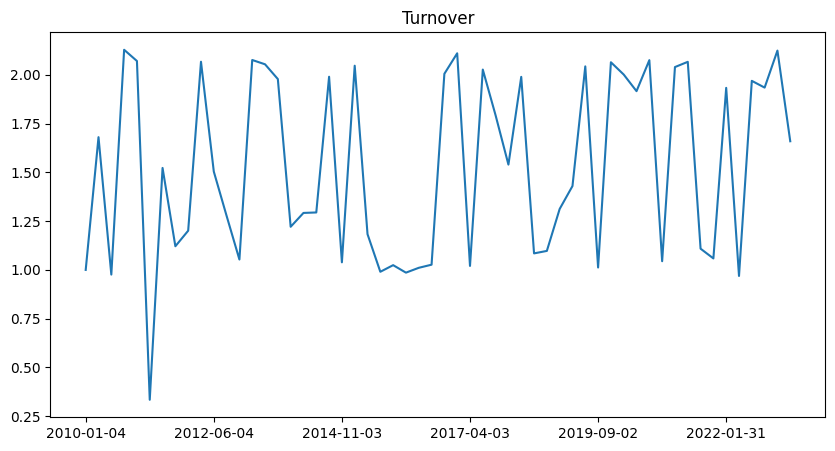

In [61]:
bt_mv.strategy.turnover(
    return_series = data['return_series'],
    rescale = True,
).plot(title = 'Turnover', figsize = (10, 5))


Simulate with different cost assumptions.

In [ ]:
return_series = bs.data['return_series']

sim_mv_gross = bt_mv.strategy.


simulate(return_series=return_series, fc=0, vc=0)
sim_mv_net_of_fc = bt_mv.strategy.simulate(return_series=return_series, fc=0.01, vc=0)
sim_mv_net_of_vc = bt_mv.strategy.simulate(return_series=return_series, fc=0, vc=0.002)
sim_mv_net = bt_mv.strategy.simulate(return_series=return_series, fc=0.01, vc=0.002)


Plot the cumulative returns.

<Axes: xlabel='Index'>

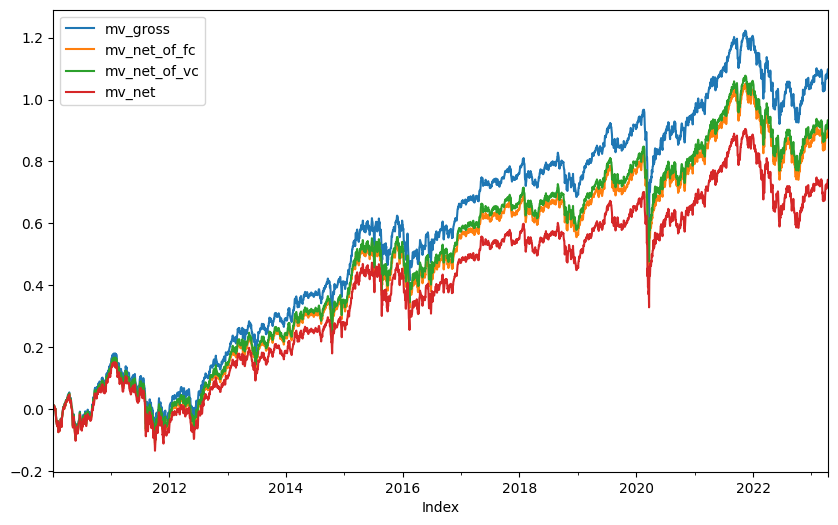

In [63]:
sim = pd.concat({
    'mv_gross': sim_mv_gross,
    'mv_net_of_fc': sim_mv_net_of_fc,
    'mv_net_of_vc': sim_mv_net_of_vc,
    'mv_net': sim_mv_net,
}, axis = 1).dropna()


np.log((1 + sim)).cumsum().plot(figsize = (10, 6))

3: Descriptive Statistics

(3 points)

Generate a table with descriptive statistics of the simulations. Include the following statistics:
- cumulative return (i.e., the return over the entire simulation period)
- annualized average returns
- annualized volatility
- sharpe ratio
- maximum drawdown

In [64]:
# <your code here>

# Basic descriptive statistics
desc_stats = sim.describe().T
desc_stats['median'] = sim.median()
desc_stats['skew'] = sim.skew()
desc_stats['kurtosis'] = sim.kurtosis()
print("Basic Statistics:")
display(desc_stats)

# Assuming 252 trading days per year for annualization
trading_days = 252

# Financial metrics
financial_stats = pd.DataFrame(index=sim.columns)

# Annualized return
financial_stats['Ann. Return (%)'] = sim.mean() * trading_days * 100

# Annualized volatility
financial_stats['Ann. Volatility (%)'] = sim.std() * np.sqrt(trading_days) * 100

# Sharpe ratio (assuming 0% risk-free rate for simplicity)
financial_stats['Sharpe Ratio'] = financial_stats['Ann. Return (%)'] / financial_stats['Ann. Volatility (%)']

# Maximum drawdown
cum_returns = (1 + sim).cumprod()
running_max = cum_returns.cummax()
drawdown = (cum_returns / running_max - 1)
financial_stats['Max Drawdown (%)'] = drawdown.min() * 100

# Win ratio (percentage of positive returns)
financial_stats['Win Ratio (%)'] = (sim > 0).mean() * 100

print("\nFinancial Metrics:")
display(financial_stats)

# Correlation matrix
print("\nCorrelation Matrix:")
display(sim.corr())

Basic Statistics:


,count,mean,std,min,25%,50%,75%,max,median,skew,kurtosis
mv_gross,3466.0,0.000360,0.009288,-0.087041,-0.004146,0.000548,0.005228,0.091654,0.000548,-0.242937,8.251192
mv_net_of_fc,3466.0,0.000304,0.009288,-0.087081,-0.004187,0.000472,0.005178,0.091614,0.000472,-0.242348,8.249149
mv_net_of_vc,3466.0,0.000312,0.009295,-0.087041,-0.004201,0.000452,0.005215,0.091654,0.000452,-0.240764,8.226310
mv_net,3466.0,0.000256,0.009295,-0.087081,-0.004240,0.000394,0.005166,0.091614,0.000394,-0.240180,8.224216



Financial Metrics:


,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%),Win Ratio (%)
mv_gross,9.071834,14.743567,0.615308,-30.749402,53.894980
mv_net_of_fc,7.671949,14.743871,0.520348,-30.841213,53.087132
mv_net_of_vc,7.861694,14.755159,0.532810,-31.031208,53.519908
mv_net,6.461810,14.755468,0.437926,-31.122657,52.740912



Correlation Matrix:


,mv_gross,mv_net_of_fc,mv_net_of_vc,mv_net
mv_gross,1.000000,0.999994,0.999093,0.999086
mv_net_of_fc,0.999994,1.000000,0.999087,0.999093
mv_net_of_vc,0.999093,0.999087,1.000000,0.999994
mv_net,0.999086,0.999093,0.999994,1.000000
